#Часть 1 — Анализ дифференциальной экспрессии (DESeq2)



##1) Задача

Выявить гены с дифференциальной экспрессией между пациентами с раком лёгкого, ответившими (R) и не ответившими (NR) на терапию иммунно-чекпоинтными ингибиторами (ICI). Такие гены могут служить потенциальными биомаркерами ответа на иммунотерапию

##2) Данные

`raw_counts_ici_samples.tsv` - сырые счётчики RNA-seq. Строки - гены (их ID), столбцы — пациенты. На пересечении - количество ридов которые выровнялись на данный ген у данного пациента

`meta_responses.tsv` - метаданные, содержащие информацию о группе, к котрой относится каждый пациент — R (ответил на иммунотерапию), NR (не ответил)

`gene_length.tsv` - таблица с длинами генов (используется для TPM нормализации)

`hgnc_complete_set.txt` - таблица, содержащая соответствия между Ensembl ID и читаемыми названиями генов (используется в части с построением volcano plot)

##3) PCA анализ

Перед основным анализом проведем контроль качества данных и оценим разделимость групп


*   Загрузим данные

In [ ]:
# @title
!pip install adjustText
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from adjustText import adjust_text

In [3]:
raw_counts = pd.read_csv("raw_counts_ici_samples.tsv", sep='\t', index_col=0)
raw_counts

,LuC-136_S6_ME_L001_R1_001ReadsPerGene,LuC-128_S14_ME_L001_R1_001ReadsPerGene,LuC-95_S5_ME_L001_R1_001ReadsPerGene,LuC-135_S12_ME_L001_R1_001ReadsPerGene,LuC2_S6_L007_R1_001ReadsPerGene,LuC-84_S5_ME_L001_R1_001ReadsPerGene,Luc_65_S30_R1_001ReadsPerGene,LuC_59_S1_R1_001ReadsPerGene,LuC-98_S11_ME_L001_R1_001ReadsPerGene,LuC-80c_S10_ME_L001_R1_001ReadsPerGene,...,LuC-91_S1_ME_L001_R1_001ReadsPerGene,Luc_66_S24_R1_001ReadsPerGene,Luc_63_S22_R1_001ReadsPerGene,LuC-123_S13_ME_L001_R1_001ReadsPerGene,LuC-43_S12_R1_001ReadsPerGene,LuC-17_S8_R1_001ReadsPerGene,LuC_54_S12_R1_001ReadsPerGene,LuC_27_S10_R1_001ReadsPerGene,LuC-85_CGRNAReadsPerGene,LuC-111_S3_ME_L001_R1_001ReadsPerGene
ENSG00000223972,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000227232,0,0,0,0,0,4,0,0,0,0,...,1,0,0,2,0,0,0,0,78,0
ENSG00000278267,1,0,0,3,0,3,0,0,1,0,...,0,0,0,0,0,0,0,0,8,2
ENSG00000243485,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
ENSG00000284332,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,78,101,45,92,30,116,0,0,19,4,...,21,27,18,174,16,69,52,42,229,72
ENSG00000275405,2,15,2,0,0,2,0,0,0,0,...,1,0,0,3,0,0,0,5,14,2
ENSG00000275987,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
ENSG00000277475,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,2,0


In [4]:

sample_metadata = pd.read_csv("meta_responses.tsv", sep='\t', index_col=0)
sample_metadata

,0
LuC-136_S6_ME_L001_R1_001ReadsPerGene,NR
LuC-128_S14_ME_L001_R1_001ReadsPerGene,R
LuC-95_S5_ME_L001_R1_001ReadsPerGene,NR
LuC-135_S12_ME_L001_R1_001ReadsPerGene,NR
LuC2_S6_L007_R1_001ReadsPerGene,NR
...,...
LuC-17_S8_R1_001ReadsPerGene,NR
LuC_54_S12_R1_001ReadsPerGene,NR
LuC_27_S10_R1_001ReadsPerGene,R
LuC-85_CGRNAReadsPerGene,NR


In [5]:
gene_lengths = pd.read_csv("gene_length.tsv", sep='\t', index_col=0)['median_trna_lenght']
gene_lengths

,median_trna_lenght
Gene_id,
ENSG00000223972,1140.0
ENSG00000227232,1340.0
ENSG00000278267,67.0
ENSG00000243485,621.0
ENSG00000284332,137.0
...,...
ENSG00000271254,2500.0
ENSG00000275405,163.0
ENSG00000275987,143.0


* Нормализуем методом TPM чтобы убрать источники технических различий внутри данных

In [6]:
# @title
sample_metadata = sample_metadata[sample_metadata['0'].isin(['R', 'NR'])]

common_samples = raw_counts.columns.intersection(sample_metadata.index)
raw_counts = raw_counts[common_samples]
sample_metadata = sample_metadata.loc[common_samples]


#TPM нормализация
dataset_normalized = raw_counts.copy().astype(float)
for gene in dataset_normalized.index:
    if gene in gene_lengths.index:
        dataset_normalized.loc[gene] = dataset_normalized.loc[gene] / gene_lengths[gene] * 10**3

dataset_normalized = dataset_normalized.div(dataset_normalized.sum(axis=0)) * 10**6
dataset_normalized

,LuC-136_S6_ME_L001_R1_001ReadsPerGene,LuC-128_S14_ME_L001_R1_001ReadsPerGene,LuC-95_S5_ME_L001_R1_001ReadsPerGene,LuC-135_S12_ME_L001_R1_001ReadsPerGene,LuC2_S6_L007_R1_001ReadsPerGene,LuC-84_S5_ME_L001_R1_001ReadsPerGene,Luc_65_S30_R1_001ReadsPerGene,LuC_59_S1_R1_001ReadsPerGene,LuC-80c_S10_ME_L001_R1_001ReadsPerGene,LuC-81_S1_ME_L001_R1_001ReadsPerGene,...,LuC-91_S1_ME_L001_R1_001ReadsPerGene,Luc_66_S24_R1_001ReadsPerGene,Luc_63_S22_R1_001ReadsPerGene,LuC-123_S13_ME_L001_R1_001ReadsPerGene,LuC-43_S12_R1_001ReadsPerGene,LuC-17_S8_R1_001ReadsPerGene,LuC_54_S12_R1_001ReadsPerGene,LuC_27_S10_R1_001ReadsPerGene,LuC-85_CGRNAReadsPerGene,LuC-111_S3_ME_L001_R1_001ReadsPerGene
ENSG00000223972,0.000000,0.000000,0.000000,0.000000,0.092012,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
ENSG00000227232,0.000000,0.000000,0.000000,0.000000,0.000000,0.187982,0.0,0.0,0.000000,0.000000,...,0.056725,0.000000,0.000000,0.126619,0.000000,0.000000,0.00000,0.000000,2.192455,0.000000
ENSG00000278267,1.780016,0.000000,0.000000,7.979186,0.000000,2.819730,0.0,0.0,0.000000,1.107834,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,4.497344,1.993452
ENSG00000243485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.122402,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
ENSG00000284332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000271254,3.720945,3.684658,2.996449,6.557827,1.258724,2.921992,0.0,0.0,1.211289,2.404885,...,0.638498,1.251387,1.142218,5.904492,0.521382,2.184037,1.95084,1.255719,3.450137,1.923283
ENSG00000275405,1.463326,8.393044,2.042569,0.000000,0.000000,0.772687,0.0,0.0,0.000000,0.910734,...,0.466329,0.000000,0.000000,1.561374,0.000000,0.000000,0.00000,2.292798,3.235053,0.819394
ENSG00000275987,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.263393,0.000000
ENSG00000277475,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.095339,0.00000,0.000000,0.090760,0.000000


*   Отрисуем точеченый график главных компонент и посмотрим на распределение

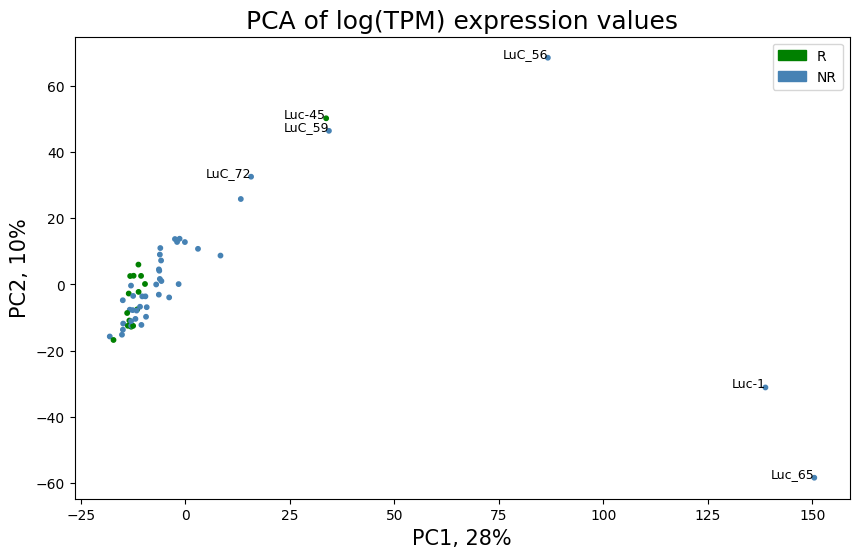

In [7]:
# @title
plt.figure(figsize=(10, 6))

pca = PCA(n_components=2)
pca_res = pca.fit_transform(dataset_normalized.apply(lambda x: np.log10(x+1)).T).T

colors = sample_metadata['0'].map({'R': 'green', 'NR': 'steelblue'})
plt.scatter(pca_res[0], pca_res[1], s=10, c=colors)

expl_var = pca.explained_variance_ratio_

plt.xlabel(f'PC1, {round(expl_var[0]*100)}%', fontsize=15)
plt.ylabel(f'PC2, {round(expl_var[1]*100)}%', fontsize=15)


threshold_pc1 = 25
threshold_pc2 = 30   #подписываем только выбросы
for i, label in enumerate(dataset_normalized.columns):
    if abs(pca_res[0][i]) > threshold_pc1 or abs(pca_res[1][i]) > threshold_pc2:
        plt.text(pca_res[0][i], pca_res[1][i], label.split('_S')[0], fontsize=9, ha='right')

plt.title('PCA of log(TPM) expression values', fontsize=18)

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='green', label='R'),
                    Patch(color='steelblue', label='NR')])
plt.show()

На PCA графике явно видим 5 выбросов: LuC_65, LuC-1, Luc_56, LuC-45, LuC_59 - их мы удалим

РС1 - объяснет 28% всей вариации данных,  РС2 - объяснет 10%. Но такие значения обусловлены именно выбросами, а не биологическими различиями между R и NR. Когда мы передаем данные DESeq2 - он предполагает, что образцы внутри группы относительно однородны, однако один сильный выброс может либо сделать многие гены «значимыми» искусственно, либо наоборот скрыть настоящие дифференциально экспрессированные гены

*   Посмотрим на график после удаления 5 образцов

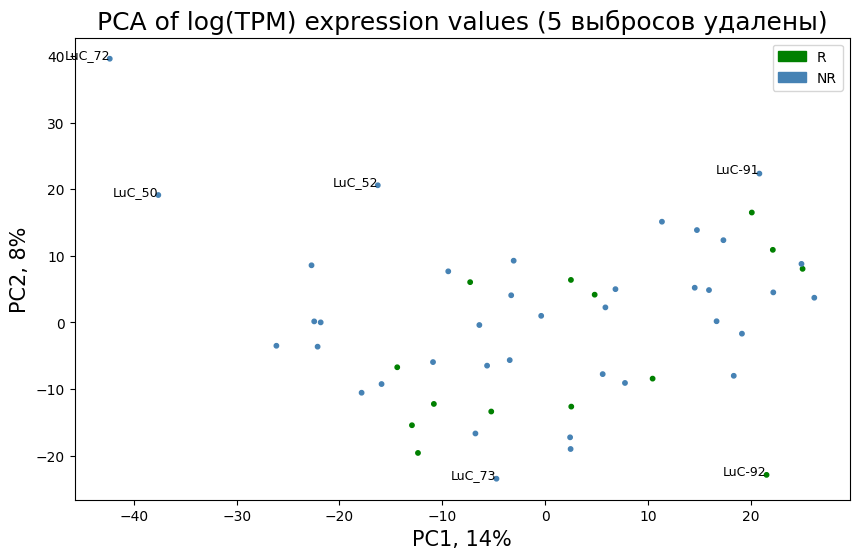

In [8]:
# @title
outliers = ['Luc_65_S30_R1_001ReadsPerGene',
            'LuC_59_S1_R1_001ReadsPerGene',
            'LuC_56_S19_R1_001ReadsPerGene',
            'Luc-1_S10_R1_001ReadsPerGene',
            'Luc-45_S5_R1_001ReadsPerGene']
dataset_clean = dataset_normalized.drop(columns=outliers)
sample_metadata_clean = sample_metadata.drop(index=outliers)

# Перестраиваем PCA
plt.figure(figsize=(10, 6))

pca = PCA(n_components=2)
pca_res = pca.fit_transform(dataset_clean.apply(lambda x: np.log10(x+1)).T).T

colors = sample_metadata_clean['0'].map({'R': 'green', 'NR': 'steelblue'})
plt.scatter(pca_res[0], pca_res[1], s=10, c=colors)

expl_var = pca.explained_variance_ratio_

plt.xlabel(f'PC1, {round(expl_var[0]*100)}%', fontsize=15)
plt.ylabel(f'PC2, {round(expl_var[1]*100)}%', fontsize=15)
plt.title('PCA of log(TPM) expression values (5 выбросов удалены)', fontsize=18)

threshold_pc1 = 30
threshold_pc2 = 20   #подписываем только выбросы
for i, label in enumerate(dataset_clean.columns):
    if abs(pca_res[0][i]) > threshold_pc1 or abs(pca_res[1][i]) > threshold_pc2:
        plt.text(pca_res[0][i], pca_res[1][i], label.split('_S')[0], fontsize=9, ha='right')

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='green', label='R'),
                    Patch(color='steelblue', label='NR')])
plt.show()

После удаления мы видим, что значение РС1 сразу снизилось до 14%, данные теперь более равномерно распределены. Все же можно заметить еще пару выбросов в левой части, их мы тоже удалим

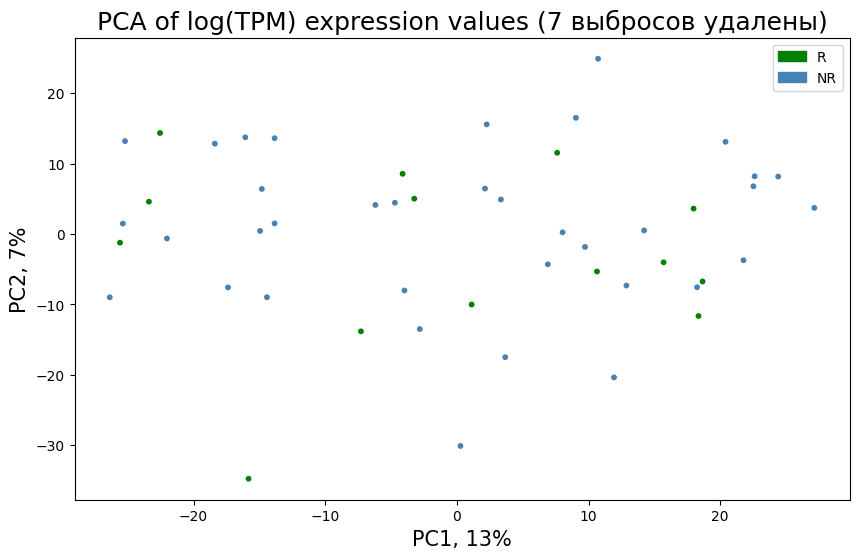

In [9]:
# @title
outliers2 = ['LuC_72_S3_R1_001ReadsPerGene', 'LuC_50_S5_R1_001ReadsPerGene']
dataset_clean = dataset_clean.drop(columns=outliers2)
sample_metadata_clean = sample_metadata_clean.drop(index=outliers2)

plt.figure(figsize=(10, 6))

pca = PCA(n_components=2)
pca_res = pca.fit_transform(dataset_clean.apply(lambda x: np.log10(x+1)).T).T

colors = sample_metadata_clean['0'].map({'R': 'green', 'NR': 'steelblue'})
plt.scatter(pca_res[0], pca_res[1], s=10, c=colors)

expl_var = pca.explained_variance_ratio_

plt.xlabel(f'PC1, {round(expl_var[0]*100)}%', fontsize=15)
plt.ylabel(f'PC2, {round(expl_var[1]*100)}%', fontsize=15)
plt.title('PCA of log(TPM) expression values (7 выбросов удалены)', fontsize=18)

from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='green', label='R'),
                    Patch(color='steelblue', label='NR')])
plt.show()

**Вывод:** После удаления выбросов PCA не выявил чёткого разделения между группами R и NR (при чем ни на одной из компонент, я также пробовала PC3/PC4). PC1 объясняет 13% дисперсии, PC2 - 11%, что указывает на отсутствие выраженных глобальных транскриптомных различий между группами (возможно причина в том, что различия между R и NR включают в себя небольшую группу генов, а не весь транскриптом)

Также, глядя на график,  сложно однозначно сказать о присутствии  batch effect, тк нет данных об условиях приготовления образцов. Однако визуально группы R и NR распределены равномерно без видимой технической кластеризации



##4) Clustermap образцов


Построим clustermap и посморим, насколько похожи профили экспрессии генов между образцами (возьмем 1500 самых вариабельных)

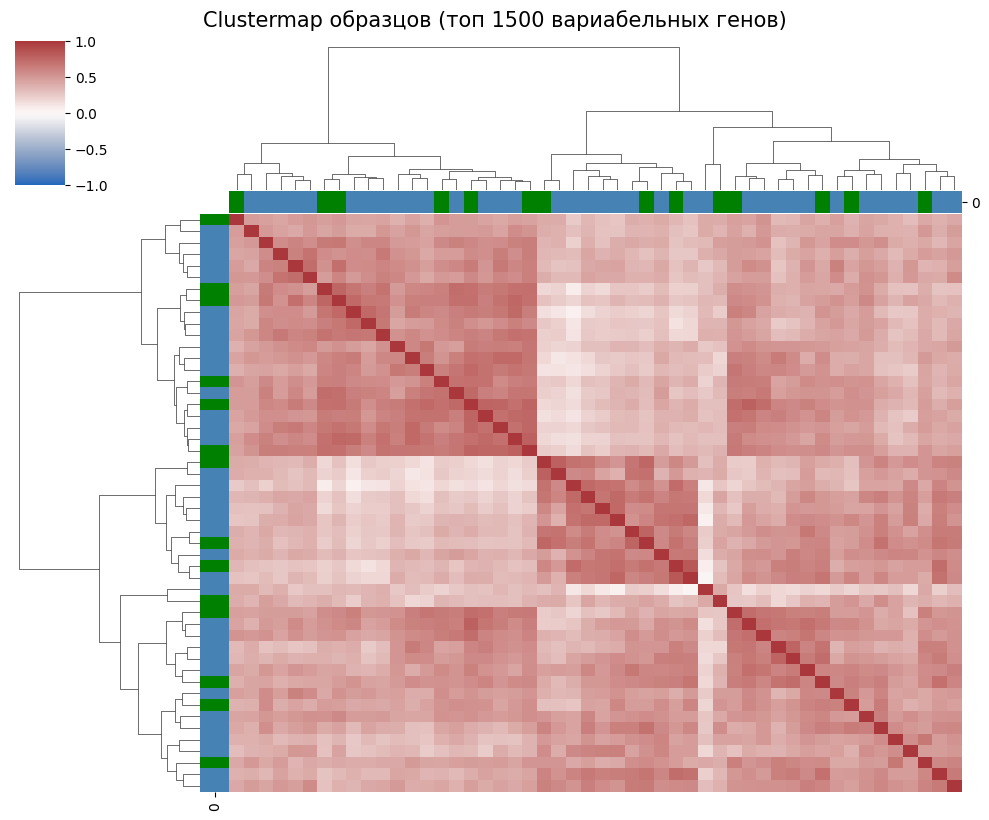

In [18]:
# @title
import seaborn as sns

log_tpm = dataset_clean.apply(lambda x: np.log10(x + 1))
top_genes = log_tpm.var(axis=1).nlargest(1500).index
log_tpm_top = log_tpm.loc[top_genes]

corr_matrix = log_tpm_top.corr(method='pearson')

lut = {'R': 'green', 'NR': 'steelblue'}
col_colors = sample_metadata_clean['0'].map(lut)

sns.clustermap(
    corr_matrix,
    figsize=(10, 8),
    col_colors=col_colors,
    row_colors=col_colors,
    method='ward',
    metric='euclidean',
    cmap='vlag',
    center=0,
    vmin=-1,
    vmax=1,
    xticklabels=False,
    yticklabels=False
)
plt.suptitle('Clustermap образцов (топ 1500 вариабельных генов)',
             y=1.02, fontsize=15)
plt.show()

R образцы не формируют отдельного кластера - они разбросаны среди NR образцов

Как и в предыдущем пункте, мы видим, что чёткого разделения между группами нет. Это также подтверждает предположение о том, что различия не очень сильные на уровне всего транскриптома, они скорее носят локальный характер

##5) DESeq2


Тк DESeq2 имеет свою систему нормализации, мы подадим raw_counts датасет с удаленными выбросами

*   С помощью R-скрипта `DESeq2_script` получим таблицу результатов `DEG_results.tsv`

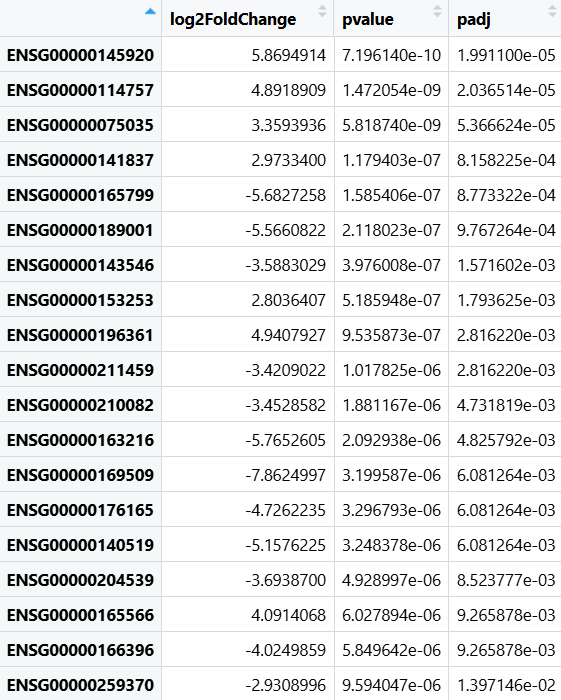

Столбцы:

**log2FoldChange** - во сколько раз изменилась экспрессия гена в R относительно NR в логарифмической шкале (положительное значениe ⇒ выше экспрессия у R)

**pvalue** - p-value статистического теста, без поправки

**padj** - p-value с поправкой на множественное тестирование (насколько мы можем быть уверены, что изменение экспрессии гена не случайность, с учётом того, что мы проверяли тысячи генов одновременно)

*  Этот же скрипт строит по полученным результатам volcano plot (используем также библиотеку для перевода Ensembl_ID → Gene Symbol)

    Пороги значимости:

    padj < 0.01

    |log2FC| > 2



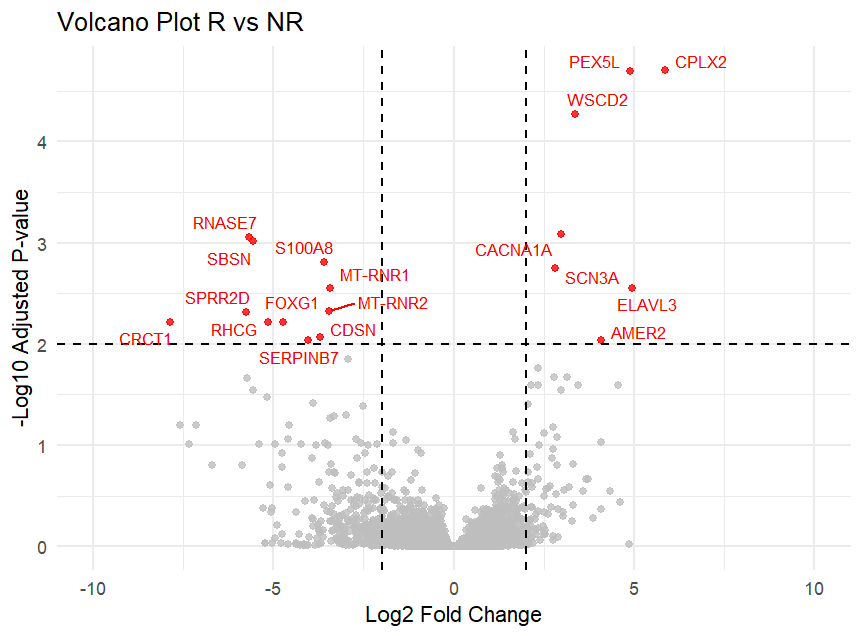

**Вывод:** На графике видим небольшое количество значимых генов, что согласуется с отсутствием глобальных различий на PCA и clustermap. Большее количество генов сосредоточено в левой сторое ⇒ у группы пациентов, ответивших на лечение (R) данные гены экспрессированы меньше

Например группа генов RNASE7, SBSN, SPRR2D, CRCT1, RHCG, S100A8 связана с кожным барьером, дифференцировкой эпителия и иммунной защитой, их повышенная экспрессия у NR группы может указывать на воспаление или опухолевый процесс

У ответчиков на иммунотерапию (R) снижена экспрессия эпителиальных и воспалительных генов, но при этом повышена экспрессия группы генов, связаных с нейрональными функциями (например CACNA1A, SCN3A - гены кальциевого и натриевого каналов соотвественно, CPLX2 - белок синаптического везикулярного аппарата)

Все выявленные гены являются потенциальными биомаркерами ответа на ICI терапию и могут быть использованы для предсказания эффективности иммунотерапии у пациентов с раком лёгкого

#Часть 2 —Анализ дифференциальной экспрессии (LIMMA)

##1) Введение


**Задача:** выявить гены с дифференциальной экспрессией между пациентами с полным ответом на химиотерапию (pCR) и без ответа (pNC) при раке яичника

 Данные получены на микрочипах — это технология, при которой интенсивность флуоресцентного сигнала отражает уровень экспрессии гена. В отличие от RNA-seq, микрочиповые данные являются непрерывными и приблизительно нормально распределёнными

 *  Почему используем LIMMA?                   

    Если мы подадим микрочиповые данные в DESeq2 из предыдущей части, то дробные значения интенсивности флуоресценции вызовут ошибку или некорректную работу, тк DESeq2 основывается на анализе целых чисел (кол-во выровняшихся ридов на ген). LIMMA, в свою очередь, использует линейную модель с нормальным распределением — это как раз подходит для непрерывных нормализованных значений микрочипов


##2) Данные

`expression_for_limma2.csv` -  матрица экспрессии генов с микрочипов. Строки - gene symbols, столбцы - пациенты, на пересечении - уже нормализованные значения экспрессии

`annotation_for_limma.csv` - метаданные с клинческой ифнормацией. Нас будет интересовать колонка clinical.status.post.1st.line.chemotherapy - pCR (полный ответ на химиотерапию), pNC (нет ответа)

##3) LIMMA

При загрузке данных сразу можем заметить дисбаланс между группами (pCR - 39, pNC - 2). В группе из 2 образцов крайне сложно достоверно выявить дифференциально экспрессированные гены, поэтому наш анализ будет иметь низкую надежность


Перед анализом подготовим данные и уберем низкоэкспрессируемые гены, тк они  имеют высокую техническую вариабельность и вносят шум (берем топ 50%)

*  При помощи R-скрипта `LIMMA` оценим насколько много находится значимых генов для трех значений порога |LogFC| > 1, 2, 3 (порог pvalue/padj фиксированный < 0.05)

    Выведем и сохраним таблицу `DEG_limma_results.tsv`

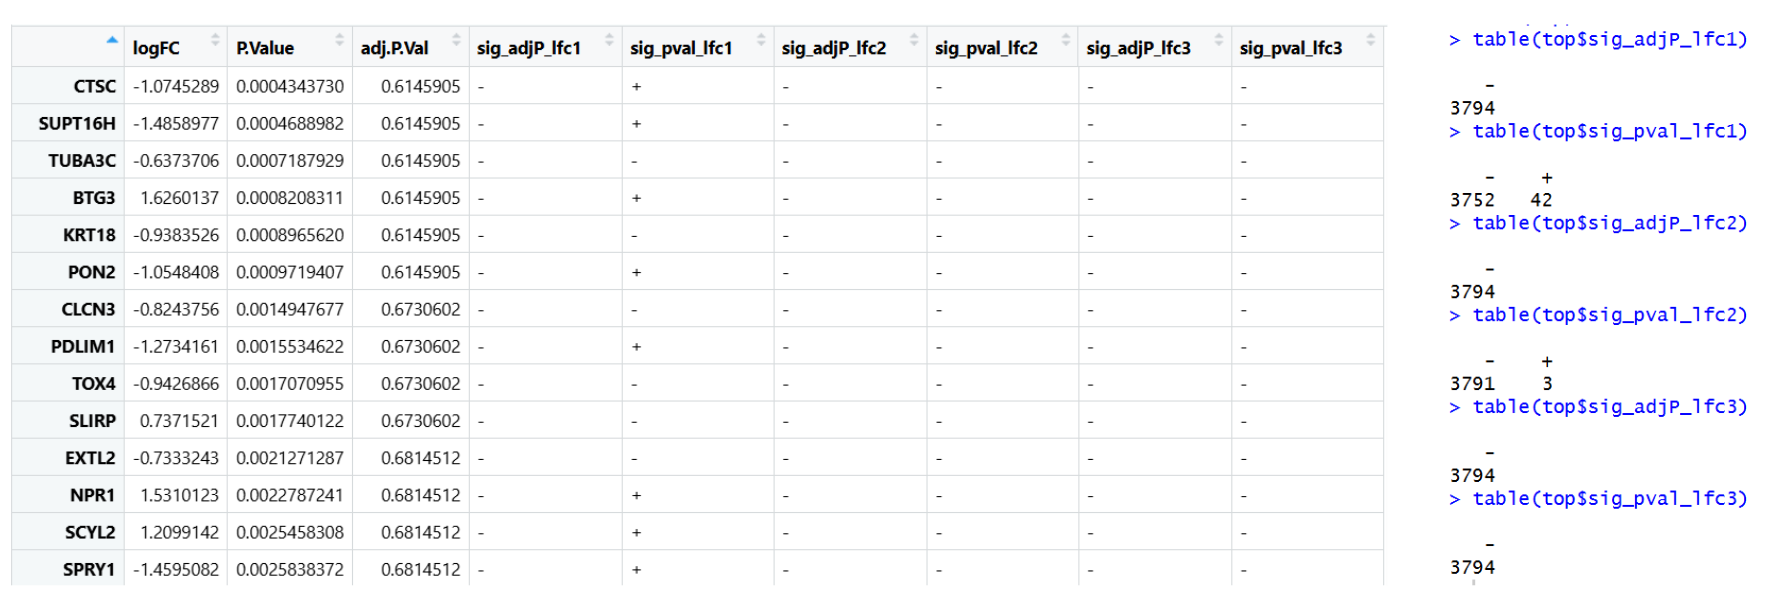

Мы видим, что минимальное значение adj.P.Val = 0.615, то есть с нашим стандартным порогом для этого параметра - мы получаем 0 значимых генов. При использовании сырых p-value и |LogFC| > 1 находится 42 гена, однако этим результатам нельзя доверять как раз из-за отсутствия поправки на множественное тестирование.

Как и предполагалось -  малый размер группы pNC существенно снижает статистическую мощность анализа, ухудшает оценку дисперсии и повышает вероятность как ложноположительных, так и ложноотрицательных результатов

##4) Визуализация

Тк наша задача заключается в сравнении порогов LogFC, то для построения volcano plot мы возьмем логарифм p-value вместо padj, иначе графики будут пустыми и неинформативными

*   Используя тот же скрипт `LIMMA` построим графки с тремя пороговыми значениями

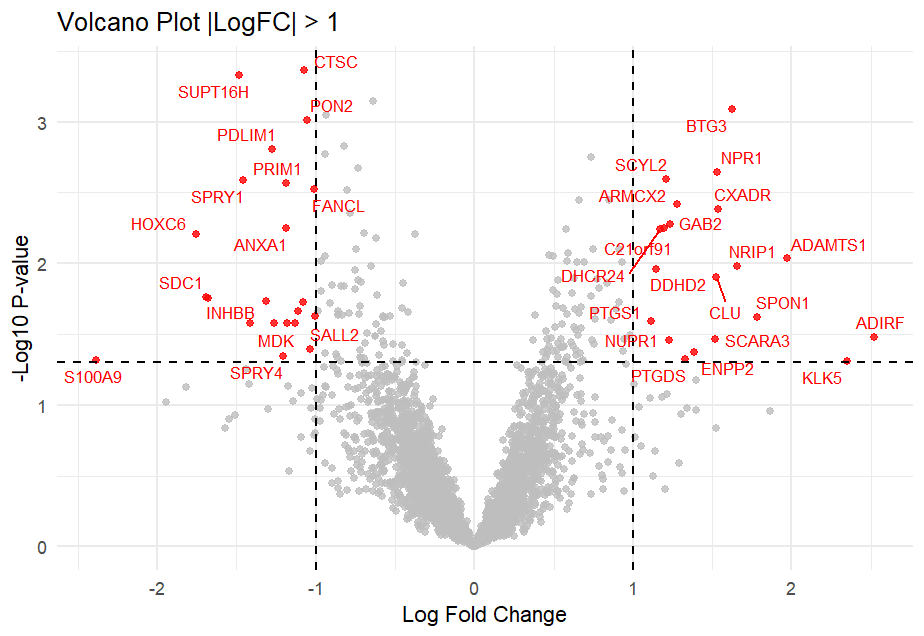

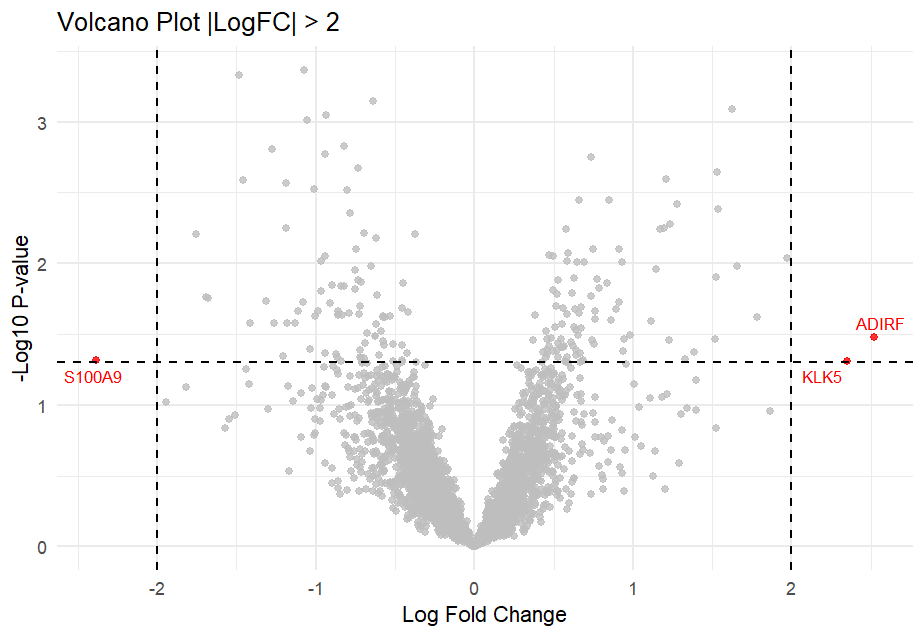

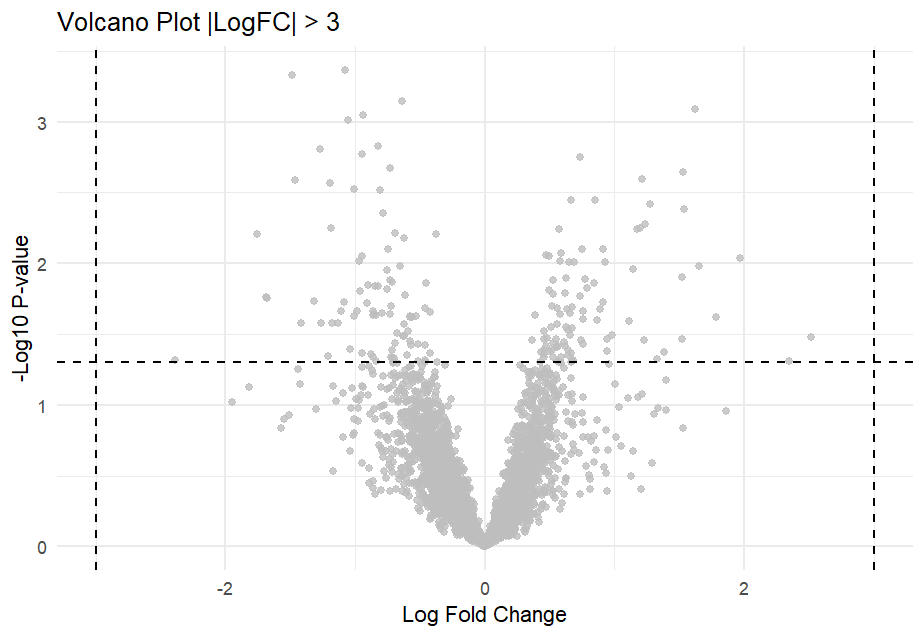

**Выводы:** Как мы и наблюдали по таблице - при |LogFC| > 1 - 42 значимых гена, при |LogFC| > 2 - 3 гена, такого количества недостаточно для биологических выводов. Для |LogFC| > 3 анализ просто не имеет смысла

Для данного анализа оптимальным порогом является |LogFC| > 1:

*   Это минимальный биологически значимый уровень и он все же позволяет выявить умеренные, но потенциально важные изменения в экспрессии

*   Для нашего датасета - это единственный порог, при котором остаётся достаточное количество генов для дальнейшего анализа  




**Биологическая интерпретация:**

Рассмотрим первый график - распределение генов по обоим сторонам равное

Левая сторона показывает гены, которые сильнее экспрессированы у pNC. В основном это гены связанные с иммуносупрессией (S100A9, ANXA1) и резистентностью к терапии (MDK)

У группы пациентов, ответивших на химиотерапию (pCR) заметно значима экспрессия гена BTG3 -  супрессора опухолей,который тормозит клеточный цикл, большинство остальных генов создают благоприятное микроокружение для действия препаратов

